# Speech Emotion Recognition — model

Convert RAVDESS clips into mel-spectrograms, split by speaker, and train a CNN to
classify 8 emotions. Run top to bottom (Restart & Run All).

## Setup

Labels and the actor id are both encoded in the RAVDESS filename
(`03-01-05-01-02-01-12.wav` → 3rd field = emotion, 7th field = actor).

In [1]:
import os
import glob
import random
import numpy as np
import librosa
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = os.path.join("..", "data", "raw")

EMOTIONS = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}


def emotion_from_filename(path):
    return EMOTIONS[os.path.basename(path).split("-")[2]]


def actor_from_filename(path):
    return int(os.path.basename(path).split("-")[6].split(".")[0])


files = glob.glob(os.path.join(DATA_DIR, "Actor_*", "*.wav"))
len(files)

1440

## Spectrograms

Each clip becomes a `(128, width)` mel-spectrogram. Width depends on clip length, so
pad short ones / truncate long ones to a fixed 130 columns before feeding a CNN.

In [2]:
MAX_LEN = 130


def fix_width(mel_db, max_len=MAX_LEN):
    w = mel_db.shape[1]
    if w > max_len:
        return mel_db[:, :max_len]
    return np.pad(mel_db, ((0, 0), (0, max_len - w)))


def wav_to_spectrogram(path):
    y, _ = librosa.load(path, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=22050, n_mels=128)
    return fix_width(librosa.power_to_db(mel, ref=np.max))

Build the full dataset and cache it so we don't recompute.

In [3]:
X = np.stack([wav_to_spectrogram(f) for f in files]).astype(np.float32)
y = np.array([emotion_from_filename(f) for f in files])

np.save("../data/processed/X.npy", X)
np.save("../data/processed/y.npy", y)
X.shape, y.shape

((1440, 128, 130), (1440,))

## Preprocessing

Encode emotion strings to integers, scale the dB values to `[0, 1]`, and add a channel
axis so the shape matches what a 2D CNN expects `(N, channels, H, W)`.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X = (X - X.min()) / (X.max() - X.min())
X = X[:, np.newaxis, :, :]

X.shape, list(le.classes_)

((1440, 1, 128, 130),
 [np.str_('angry'),
  np.str_('calm'),
  np.str_('disgust'),
  np.str_('fearful'),
  np.str_('happy'),
  np.str_('neutral'),
  np.str_('sad'),
  np.str_('surprised')])

## Speaker-independent split

Splitting clips randomly would leak the same actor into train and test, so the model could
memorise voices instead of emotions. Instead split *by actor*: the test set is entirely
unheard speakers.

| Split | Actors |
|-------|--------|
| Train | 1–19   |
| Val   | 20–21  |
| Test  | 22–24  |

In [5]:
actors = np.array([actor_from_filename(f) for f in files])

train_mask = actors <= 19
val_mask = (actors >= 20) & (actors <= 21)
test_mask = actors >= 22

X_train, y_train = X[train_mask], y_encoded[train_mask]
X_val, y_val = X[val_mask], y_encoded[val_mask]
X_test, y_test = X[test_mask], y_encoded[test_mask]

X_train.shape, X_val.shape, X_test.shape

((1140, 1, 128, 130), (120, 1, 128, 130), (180, 1, 128, 130))

## Data loaders

Training data gets SpecAugment (random time/frequency masking) so the model can't memorise
individual spectrograms. Validation and test stay untouched.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32


class SpecAugment(torch.utils.data.Dataset):
    def __init__(self, X, y, freq_mask=10, time_mask=12, n_masks=1):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.freq_mask, self.time_mask, self.n_masks = freq_mask, time_mask, n_masks

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        spec = self.X[idx].clone()
        _, n_mels, n_steps = spec.shape
        for _ in range(self.n_masks):
            f = random.randint(0, self.freq_mask)
            f0 = random.randint(0, max(0, n_mels - f))
            spec[:, f0:f0 + f, :] = 0
            t = random.randint(0, self.time_mask)
            t0 = random.randint(0, max(0, n_steps - t))
            spec[:, :, t0:t0 + t] = 0
        return spec, self.y[idx]


def loader(X, y, shuffle):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = DataLoader(SpecAugment(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = loader(X_val, y_val, shuffle=False)
test_loader = loader(X_test, y_test, shuffle=False)
device

device(type='cuda')

## Model

Three conv blocks (Conv → BatchNorm → ReLU → MaxPool), then a small classifier head with
dropout. The flattened size is inferred from a dummy pass so it never goes stale.

In [12]:
class EmotionCNN(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            n_flat = self.features(torch.zeros(1, 1, 128, 130)).flatten(1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_flat, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = EmotionCNN().to(device)

## Training

Track train and validation accuracy each epoch and keep the best-validation checkpoint.
The train/val gap is the overfitting signal.

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 120


def accuracy(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total


best_val = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item()

    train_acc, val_acc = accuracy(train_loader), accuracy(val_loader)
    print(f"epoch {epoch:2d} | loss {running / len(train_loader):.3f} "
          f"| train {train_acc:.3f} | val {val_acc:.3f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "../models/best_model.pt")

print("best val accuracy:", round(best_val, 3))

epoch  1 | loss 2.579 | train 0.182 | val 0.125
epoch  2 | loss 1.905 | train 0.304 | val 0.283
epoch  3 | loss 1.797 | train 0.369 | val 0.300
epoch  4 | loss 1.740 | train 0.414 | val 0.267
epoch  5 | loss 1.690 | train 0.429 | val 0.267
epoch  6 | loss 1.644 | train 0.493 | val 0.300
epoch  7 | loss 1.581 | train 0.473 | val 0.300
epoch  8 | loss 1.566 | train 0.492 | val 0.342
epoch  9 | loss 1.523 | train 0.537 | val 0.300
epoch 10 | loss 1.510 | train 0.468 | val 0.342
epoch 11 | loss 1.433 | train 0.580 | val 0.383
epoch 12 | loss 1.433 | train 0.546 | val 0.358
epoch 13 | loss 1.382 | train 0.605 | val 0.392
epoch 14 | loss 1.389 | train 0.506 | val 0.275
epoch 15 | loss 1.436 | train 0.467 | val 0.308
epoch 16 | loss 1.348 | train 0.662 | val 0.400
epoch 17 | loss 1.273 | train 0.443 | val 0.400
epoch 18 | loss 1.272 | train 0.587 | val 0.367
epoch 19 | loss 1.304 | train 0.596 | val 0.358
epoch 20 | loss 1.203 | train 0.576 | val 0.458
epoch 21 | loss 1.227 | train 0.708 | va

## Evaluation

Load the best checkpoint and report accuracy on the held-out speakers, plus a confusion
matrix to see which emotions get mixed up.

In [14]:
model.load_state_dict(torch.load("../models/best_model.pt", weights_only=True))
test_acc = accuracy(test_loader)
print(f"Test accuracy (unseen speakers): {test_acc:.3f}")

Test accuracy (unseen speakers): 0.461


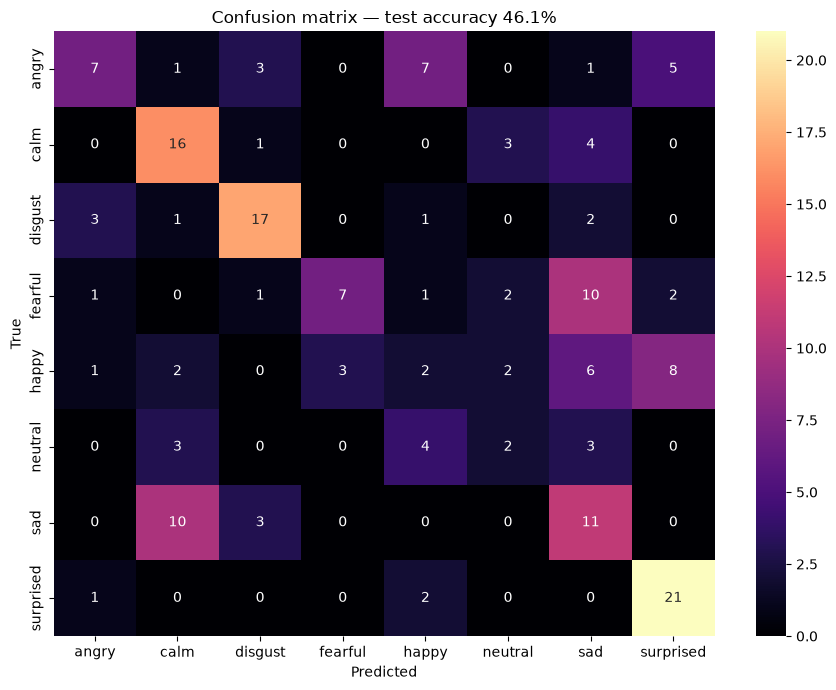

              precision    recall  f1-score   support

       angry       0.54      0.29      0.38        24
        calm       0.48      0.67      0.56        24
     disgust       0.68      0.71      0.69        24
     fearful       0.70      0.29      0.41        24
       happy       0.12      0.08      0.10        24
     neutral       0.22      0.17      0.19        12
         sad       0.30      0.46      0.36        24
   surprised       0.58      0.88      0.70        24

    accuracy                           0.46       180
   macro avg       0.45      0.44      0.42       180
weighted avg       0.47      0.46      0.44       180



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
preds, true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
        true.extend(yb.numpy())

cm = confusion_matrix(true, preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix — test accuracy {test_acc:.1%}")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(true, preds, target_names=le.classes_))